In [77]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt



In [ ]:


##  endpoint to get airport traffic "https://aerodatabox.p.rapidapi.com/flights/airports/iata/NKC/2025-01-01T20:00/2025-01-02T08:00"

## docs https://doc.aerodatabox.com/index.html#operation/GetAirportFlights
def get_airport_data(airport_code, start_date, end_date):
    '''
    Returns aircrapt departure and arrival API response dictionnary from rapidapi 

    @param: airport_code the code of the airport ex: NKC (nouakchott)
    @param: start_date the start_date of the period
    @param: end_date the end of period (SHOUD BE MAXIMUM 12 hours)

    returns a dictionnary of data
    '''

    # keep this at it is
    querystring = {"withLeg":"true",
                "direction":"Both",
                "withCancelled":"true",
                "withCodeshared":"true",
                "withCargo":"true",
                "withPrivate":"true",
                "withLocation":"false"}

    ## headers are http request headers that contain api key
    headers = {
        "x-rapidapi-key": "f8254c96f5msh4fc6742c6eaf34dp187b54jsn28b1e448b428",
        "x-rapidapi-host": "aerodatabox.p.rapidapi.com"
    }

    url = f"https://aerodatabox.p.rapidapi.com/flights/airports/iata/{airport_code}/{start_date}/{end_date}"
    response = requests.get(url, headers=headers, params=querystring)
    if response.status_code >= 299:
        raise Exception(f"Error: {response.status_code} : {response.text}")
    
    data = response.json()
    return data 

In [ ]:

def download_data_from_api(airport='NKC', start_date='2025-01-01T20:00', end_date='2025-04-01T08:00'):
    result = []
    # create a serie of dates from start_date to end_date
    dates = pd.Series(pd.date_range(start=start_date, end=end_date, freq='12h'))
    
    # iterate overdates starting from 1
    for idx in range(1, len(dates)):
        try:
            # get the data from the API
            data = get_airport_data(airport, dates.iloc[idx - 1], dates.iloc[idx])
            result.append(data) # append the result to already existing data
        except Exception as exp:
            print(f"Error occured {exp}") # print the error 
            break # stop the loop in case of an error

    with open ('airport_v1.json', 'w') as f: # open the fine in witch you wish to save the data
        json.dump(result, f)  # json.dump writes the data into the file f

    return result

In [6]:
download_data_from_api()

Error occured Error: 429 : {"message":"You have exceeded the MONTHLY quota for Tier 2 on your current plan, BASIC. Upgrade your plan at https:\/\/rapidapi.com\/aedbx-aedbx\/api\/aerodatabox"}


[]

In [98]:

def load_airpot_data(filename:str):
    ''' 
     open the file (filename) and load it into a python dictionnary
     @param filename
     @return python dictionnary
    '''
    with open (filename, 'r') as f: 
        data = json.load(f)
        return data

In [99]:
filename='./data/airport.json'
data = load_airpot_data(filename)


In [ ]:

def prepare_data(data):
    ''' 
    takes a list of records and returns a dataframe with the exact data needed
    '''
    # list comprehension to get the "departures"  field of the data as a list
    departures = ([ele["departures"] for ele in data])
    
    prepared_data = [] # list to accumulate prepared data
    # those are the keys of api response data
    # dict_keys(['departure', 'arrival', 'number', 'status', 'codeshareStatus', 'isCargo', 'aircraft', 'airline'])

    for departure_list in departures:
        for departure_dict in departure_list :
            # to access a key in a python dict you can either do 
            # dict["attribute"] or dict.get("attribute", "defailt")
            # dict["attribute"] will return a 'KeyError' exception if the attribute does not exist in the dictionnary
            # dict.get("attribute", "default") will return the default value if the attribute does not exists
            departure = departure_dict['departure']
            arrival = departure_dict['arrival']
            departure_time = departure.get('scheduledTime', {}).get('utc', None)
            arrival_time = arrival.get('scheduledTime',{}).get('utc', None)
            
            # create a dictionnary with the current row 
            # a dictionnary is a (key, value) data structure
            prepared_row = {
            'departure_time': departure_time,
            # in order to avoid having nulls we set the revisedTime to the exact time (no delay)
            'departure_revised_time': departure.get('revisedTime', {}.get('utc', departure_time)),
            'arrival_time': arrival_time,
            'arrival_revised_time': arrival.get('revisedTime',{}).get('utc', arrival_time),
            'arrival_airport_code': arrival.get('airport').get('iata'),
            'arrival_airport_name': arrival.get('airport').get('name'),
            'flight_number': departure_dict.get('number'),
            'aircraft': departure_dict.get('aircraft', {}).get('model'),
            'airline': departure_dict.get('airline').get('name'),
            } 
            prepared_data.append(prepared_row)

    # return a pandas dataframe constructed with the python list
    return pd.DataFrame(prepared_data)
        



In [ ]:

df = prepare_data(data) # create a datafame with prepared data


## Q1. How many flights does the dataset contain in total? What is the minimum data and maximum data that we have <br/>

In [102]:
print(f"The dataset contains {len(df)}  flights from {df["departure_time"].min()} to {df["departure_time"].max()}")


The dataset contains 376  flights from 2025-01-01 21:15Z to 2025-02-19 06:50Z


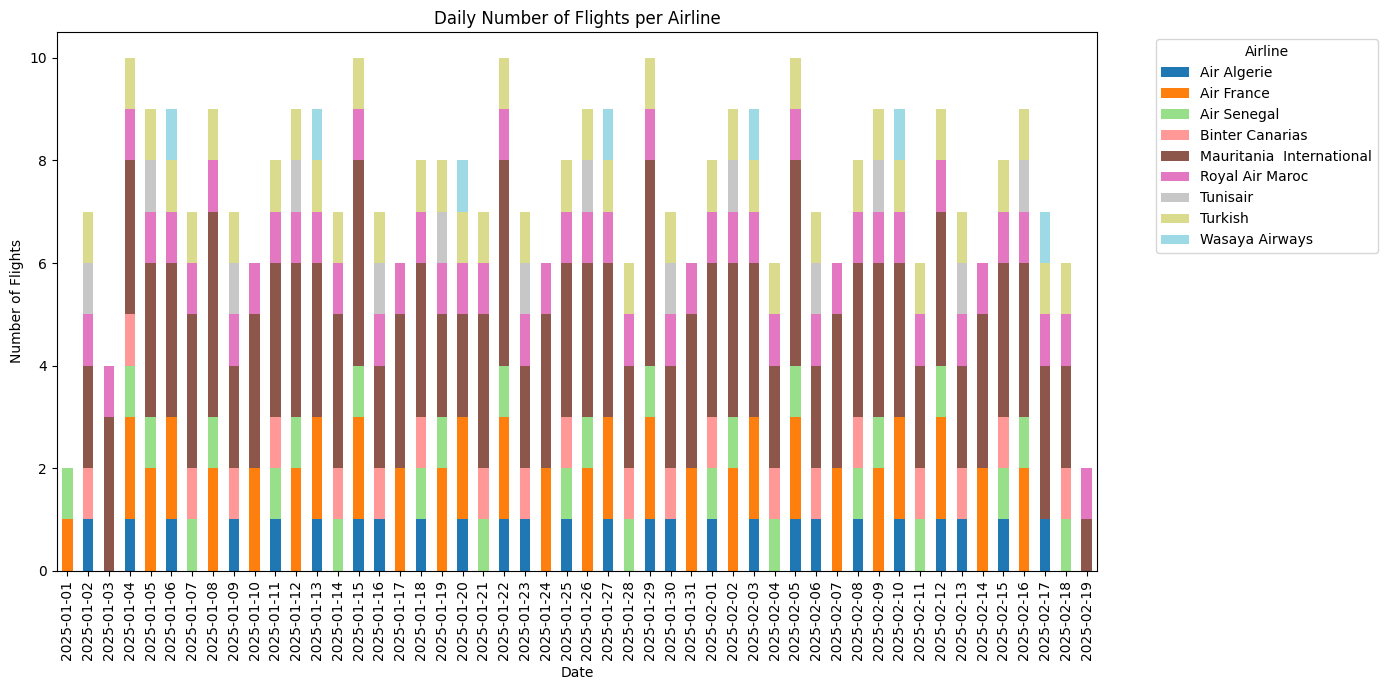

In [116]:
# convert the departure time to a datetime object
df['departure_time'] = pd.to_datetime(df['departure_time'])

# Extract just the date (drop the time part)
df['date'] = df['departure_time'].dt.date

# Group by date and airline, then count the flights
# you can print the intermediary steps to understand the difference

# print(df.groupby(['date', 'airline']))
# print(df.groupby(['date', 'airline']).size())
# print(df.groupby(['date', 'airline']).size().unstack(fill_value=0))
daily_counts = df.groupby(['date', 'airline']).size().unstack(fill_value=0)
daily_counts.plot(kind='bar', stacked=True, colormap='tab20', figsize=(14, 7))

plt.title('Daily Number of Flights per Airline')
plt.xlabel('Date')
plt.ylabel('Number of Flights')
plt.legend(title='Airline', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## Q2. How many distinct airlines are represented?<br/>


In [107]:
nb_uniq_comanies = df["airline"].nunique()
print(f"there are {nb_uniq_comanies} unique companies")

flight_counts = df.groupby('airline').size().sort_values(ascending=True)
print(flight_counts)



there are 9 unique companies
airline
Wasaya Airways                 7
Tunisair                      14
Binter Canarias               21
Air Algerie                   26
Air Senegal                   28
Turkish                       41
Royal Air Maroc               49
Air France                    53
Mauritania  International    137
dtype: int64


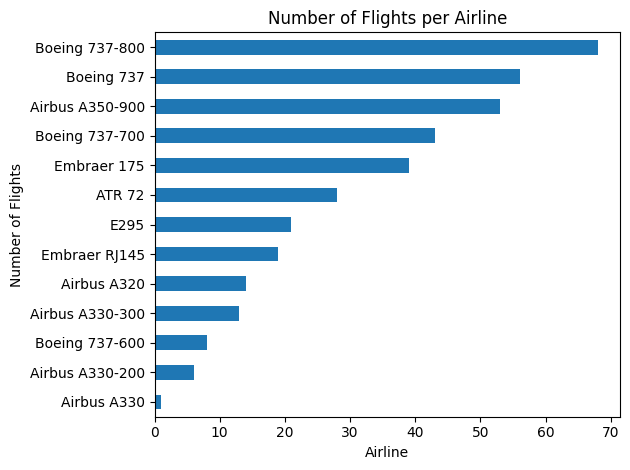

In [118]:

# PLOT THE RESULT
flight_counts.plot(kind='barh', colormap='tab20')  # You can also use 'barh' for horizontal bars

plt.title('Number of Flights per Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()


## Q3. Which aircraft models are used most and how many times?<br/>


In [119]:
flight_counts = df.groupby('aircraft').size().sort_values(ascending=True)
print(flight_counts)



aircraft
Airbus A330         1
Airbus A330-200     6
Boeing 737-600      8
Airbus A330-300    13
Airbus A320        14
Embraer RJ145      19
E295               21
ATR 72             28
Embraer 175        39
Boeing 737-700     43
Airbus A350-900    53
Boeing 737         56
Boeing 737-800     68
dtype: int64


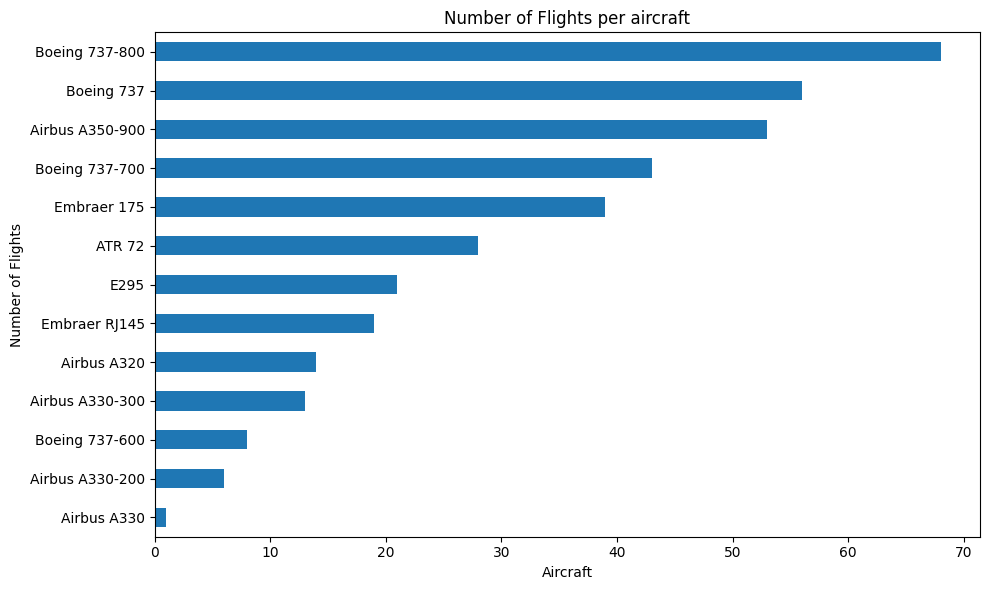

In [121]:
plt.figure(figsize=(10, 6))
flight_counts.plot(kind='barh')  # You can also use 'barh' for horizontal bars
plt.title('Number of Flights per aircraft')
plt.xlabel('Aircraft')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

## Q5. Schedule accuracy: For flights where arrival.revisedTime is available, calculate the average arrival delay (minutes).<br/>


In [123]:
df['arrival_time'] = pd.to_datetime(df['arrival_time'])
df['arrival_revised_time'] = pd.to_datetime(df['arrival_revised_time'])

# Step 2: Keep only rows where revised time is different
mask = df['arrival_time'] != df['arrival_revised_time']
df_filtered = df[mask].copy()

# Step 3: Calculate delay in minutes
df_filtered['arrival_delay_min'] = (df_filtered['arrival_revised_time'] - df_filtered['arrival_time']).dt.total_seconds() / 60

# Step 4: Group by airline and calculate average delay
average_delay_by_airline = df_filtered.groupby('airline')['arrival_delay_min'].mean().sort_values(ascending=False)

print(average_delay_by_airline)



airline
Mauritania  International    50.250000
Binter Canarias              31.761905
Air France                  -21.733333
Turkish                     -31.923077
Name: arrival_delay_min, dtype: float64


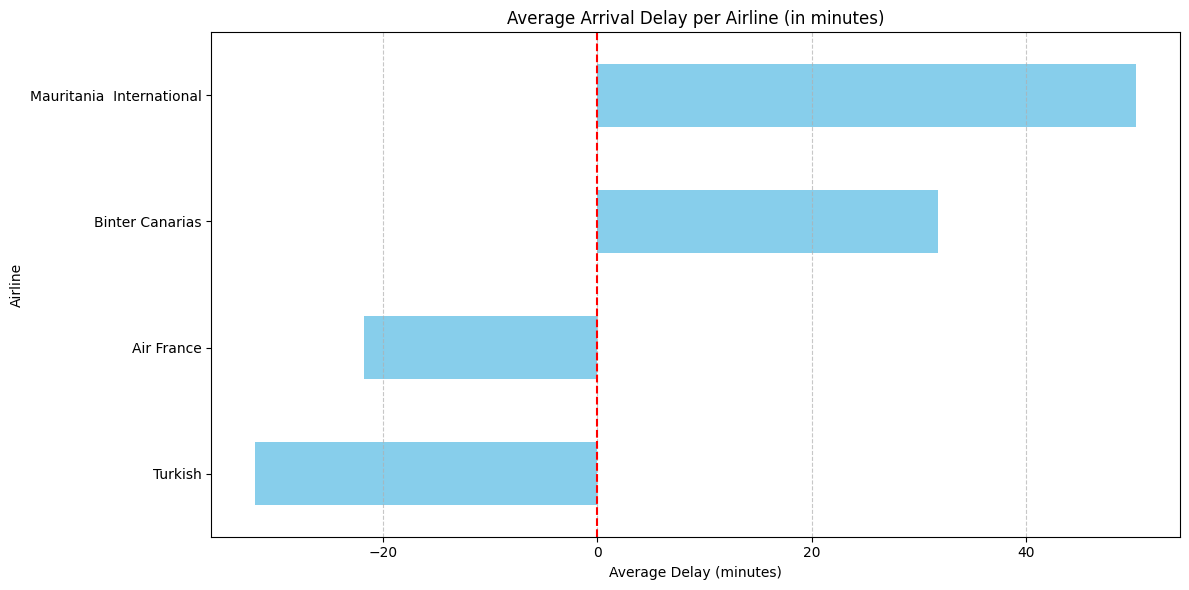

In [126]:

plt.figure(figsize=(12, 6))
average_delay_by_airline.sort_values().plot(kind='barh', color='skyblue')

plt.axvline(0, color='red', linestyle='--')  # Add a red line at 0 delay
plt.title('Average Arrival Delay per Airline (in minutes)')
plt.xlabel('Average Delay (minutes)')
plt.ylabel('Airline')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Q6. Route mapping: Create a mini‑table with the top‑3 most common city‑pairs (origin‑>destination IATA codes) and the associated flight counts.<br/>

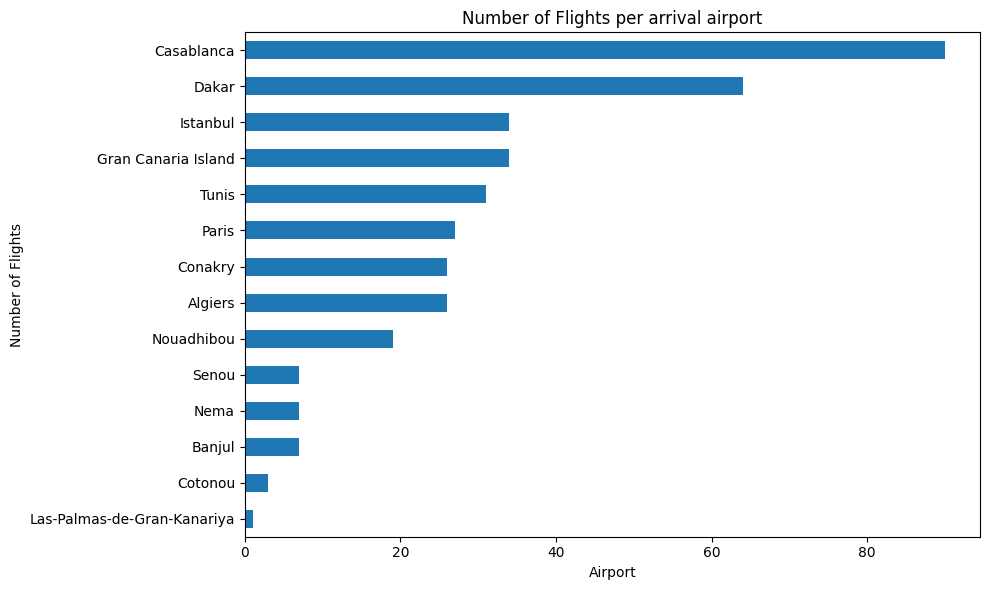

In [127]:
flight_counts = df.groupby('arrival_airport_name').size().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
flight_counts.plot(kind='barh')  # You can also use 'barh' for horizontal bars
plt.title('Number of Flights per arrival airport')
plt.xlabel('Airport')
plt.ylabel('Number of Flights')
plt.tight_layout()
plt.show()

## CONGRATS ON FINISHING THE EXERCICE